# Filtering and Parameter Estimation in Nonlinear State Space Models 

This python notebook investigates the Kalman Filter, the Kalman Smoother, the EM algorithm and the EKF

## Filtering and Smoothing

### Kalman Filter Class

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter class for Linear-Gaussian State Space Models
class KalmanFilterLGSSM:
    """
    Kalman filter for a (possibly time-varying) Linear-Gaussian State Space Model:

        z_{t+1} = F_t z_t + w_t,      w_t ~ N(0, Q_t)
        x_t     = H_t z_t + v_t,      v_t ~ N(0, R_t)

    The class supports both:
    1. Full filtering output (predicted means/covariances, filtered means/covariances),
    2. Step-by-step recursion when only the current covariance or state estimate is needed.

    Parameters:

    F, Q, H, R :
    Model matrices. Each may either be fixed numpy arrays or functions of time t.
    m0 : 
    Initial mean of the latent state.
    C0 : 
    Initial covariance of the latent state.
    """

    def __init__(self, F, Q, H, R, m0, C0):
        self.F = F
        self.Q = Q
        self.H = H
        self.R = R

        self.m0 = np.asarray(m0, dtype=float).reshape(-1)
        self.C0 = np.asarray(C0, dtype=float)

        self.m = self.m0.copy()
        self.C = self.C0.copy()
        self.n = self.m.shape[0]

    def _mat(self, M, t):
        return M(t) if callable(M) else M

    def reset(self, m0=None, C0=None):
        """
        Reset the filter to its initial state or to a new supplied state.

        This is useful when the same KalmanFilterLGSSM object is reused
        for multiple experiments.
        """
        if m0 is None:
            self.m = self.m0.copy()
        else:
            self.m = np.asarray(m0, dtype=float).reshape(-1)

        if C0 is None:
            self.C = self.C0.copy()
        else:
            self.C = np.asarray(C0, dtype=float)

    # Prediction step of Kalman filter: returns F m_t and F C_t F^T + Q
    def predict(self, t):
        F = self._mat(self.F, t)
        Q = self._mat(self.Q, t)

        m_hat = F @ self.m
        C_hat = F @ self.C @ F.T + Q
        return m_hat, C_hat

    # Update step of Kalman filter
    def update(self, x, m_hat, C_hat, t):
        H = self._mat(self.H, t)
        R = self._mat(self.R, t)

        x = np.asarray(x, dtype=float).reshape(-1)

        # Innovation d_t = x_t - H_t \hat m_t and its covariance S_t
        d = x - (H @ m_hat)
        S = H @ C_hat @ H.T + R

        # Kalman gain K_t = C_hat H^T S^{-1}
        K = C_hat @ H.T @ np.linalg.solve(S, np.eye(S.shape[0]))

        # Posterior mean and covariance
        m_new = m_hat + K @ d
        C_new = (np.eye(self.n) - K @ H) @ C_hat

        return m_new, C_new, d, S, K

    # Perform one step of Kalman filtering: predict + update
    def step(self, x, t):
        m_hat, C_hat = self.predict(t)
        m_new, C_new, d, S, K = self.update(x, m_hat, C_hat, t)

        self.m, self.C = m_new, C_new

        return {
            "m_hat": m_hat,
            "C_hat": C_hat,
            "innovation": d,
            "S": S,
            "K": K,
            "m": m_new,
            "C": C_new,
        }

    # Kalman filter recursion over a full observation sequence
    def filter(self, xs, t0=0):
        xs = [np.asarray(x, dtype=float).reshape(-1) for x in xs]

        m_hats, C_hats = [], []
        ms, Cs = [], []
        innovations, Ss, Ks = [], [], []

        t = t0
        for x in xs:
            info = self.step(x, t)

            m_hats.append(info["m_hat"])
            C_hats.append(info["C_hat"])
            ms.append(info["m"])
            Cs.append(info["C"])
            innovations.append(info["innovation"])
            Ss.append(info["S"])
            Ks.append(info["K"])

            t += 1

        return {
            "m_hat": np.array(m_hats, dtype=float),
            "C_hat": np.array(C_hats, dtype=float),
            "m": np.array(ms, dtype=float),
            "C": np.array(Cs, dtype=float),
            "innovation": np.array(innovations, dtype=float),
            "S": np.array(Ss, dtype=float),
            "K": np.array(Ks, dtype=float),
        }



Tracking a one dimensional particle, under going a constant velocity model (Example 1 in Section 2.3)

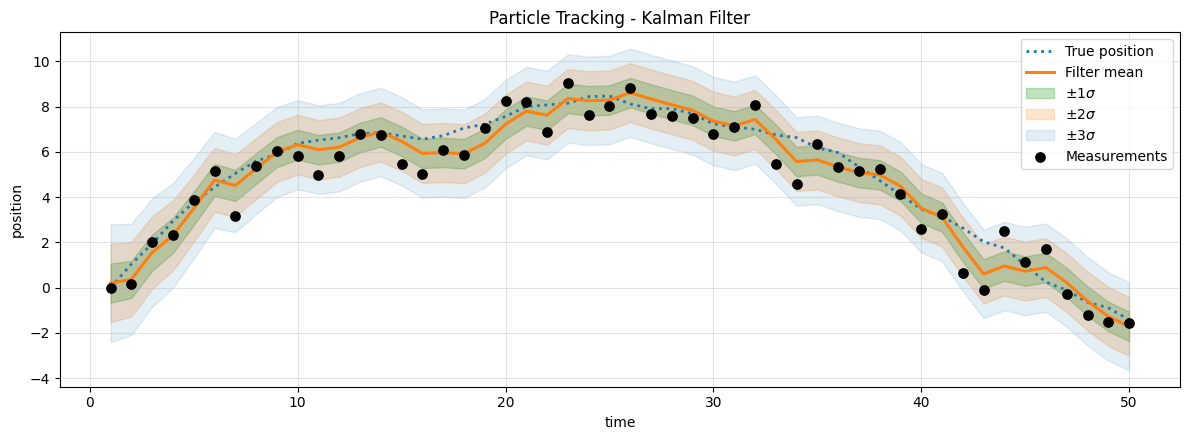

In [8]:


# Example 1: Particle tracking with uncertainty bands

# random seed for reproducibility
rng = np.random.default_rng(7)

# Time steps and time step size
T = 50
dt = 1.0

# State transition + measurement matrices
F = np.array([[1.0, dt],
              [0.0, 1.0]])
H = np.array([[1.0, 0.0]])

# Process noise + measurement noise covariances
Q = np.array([[0.02, 0.0],
              [0.0, 0.02]])
R = np.array([[1.0]])  

# True initial state z = (position, velocity)
z0_true = np.array([0.0, 1.0])

# Initial mean and covariance
m0 = np.array([0.0, 0.8])
C0 = np.array([[2.0, 0.0],
               [0.0, 1.0]])

# Generate true trajectory + noisy measurements
zs = np.zeros((T, 2))   # true latent states
xs = np.zeros((T, 1))   # measurements (position only)

z = z0_true.copy()
for t in range(T):
    # Measurement equation: x_t = H z_t + v_t
    v = rng.normal(0.0, np.sqrt(R[0, 0]), size=(1,))
    xs[t] = (H @ z).reshape(-1) + v

    # Store true latent state
    zs[t] = z

    # State evolution: z_{t+1} = F z_t + w_t
    if t < T - 1:
        w = rng.multivariate_normal(mean=np.zeros(2), cov=Q)
        z = (F @ z) + w


# Run Kalman filter
kf = KalmanFilterLGSSM(F=F, Q=Q, H=H, R=R, m0=m0, C0=C0)
out = kf.filter(xs)

# Extract filter means and covariances
m_filt = out["m"]       
C_filt = out["C"]       

pos_mean = m_filt[:, 0]
pos_std = np.sqrt(C_filt[:, 0, 0])  # posterior standard deviation for position

tgrid = np.arange(1, T + 1)

# Plot: true position, measurements, filter estimate + 1σ/2σ/3σ bands
plt.figure(figsize=(12, 4.5))
plt.title("Particle Tracking - Kalman Filter")

plt.plot(
    tgrid,
    zs[:, 0],
    linestyle=":",
    linewidth=2.0,
    label="True position"
)

plt.plot(
    tgrid,
    pos_mean,
    linewidth=2.2,
    label="Filter mean"
)

# 1st standard deviation band
plt.fill_between(
    tgrid,
    pos_mean - 1.0 * pos_std,
    pos_mean + 1.0 * pos_std,
    alpha=0.30,
    color="tab:green",
    label=r"$\pm 1\sigma$"
)

# 2nd standard deviation band
plt.fill_between(
    tgrid,
    pos_mean - 2.0 * pos_std,
    pos_mean + 2.0 * pos_std,
    alpha=0.20,
    color="tab:orange",
    label=r"$\pm 2\sigma$"
)

# 3rd standard deviation band
plt.fill_between(
    tgrid,
    pos_mean - 3.0 * pos_std,
    pos_mean + 3.0 * pos_std,
    alpha=0.12,
    color="tab:blue",
    label=r"$\pm 3\sigma$"
)

plt.scatter(
    tgrid,
    xs[:, 0],
    s=45,
    color="black",
    zorder=5,
    label="Measurements"
)

plt.xlabel("time")
plt.ylabel("position")
plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()




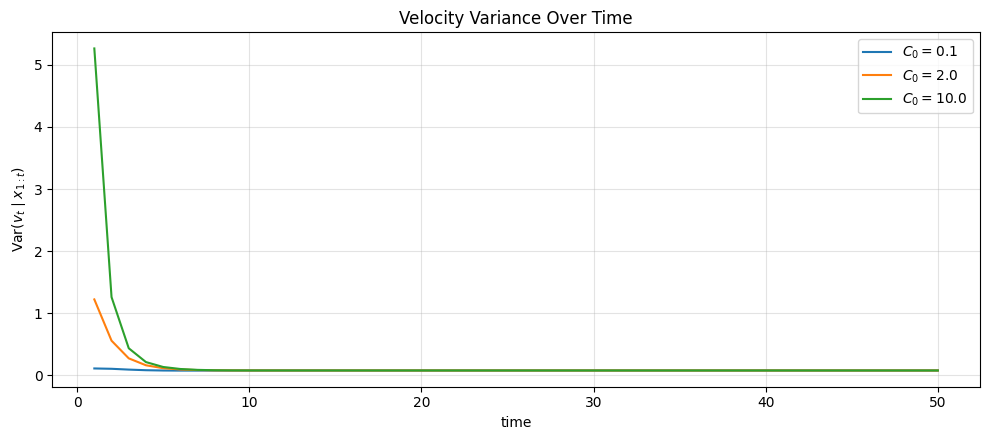

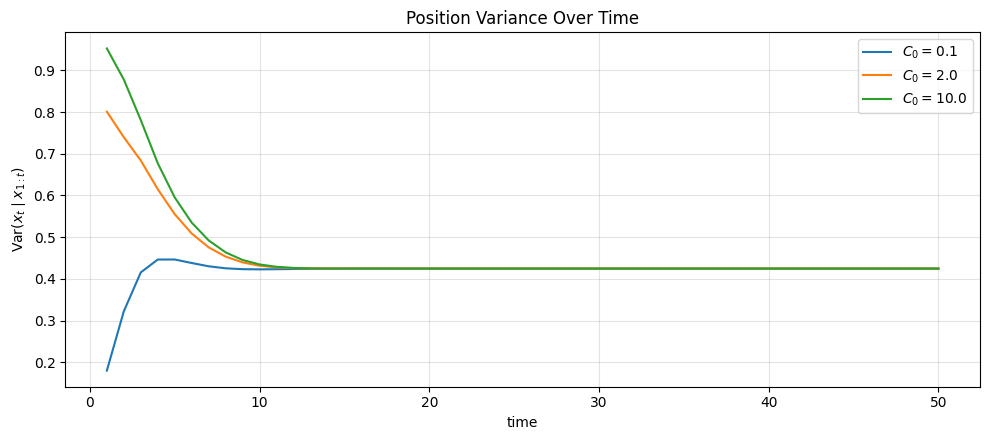

In [3]:

# Example 2: Effect of different initial covariances on filtering uncertainty

# Fixed measurement sequence (same for all runs)
rng = np.random.default_rng(7)
xs = rng.normal(0.0, np.sqrt(R[0, 0]), size=(T, 1))

# Different initial covariances
initial_covariances = {
    "$C_0 = 0.1$": np.diag([0.1, 0.1]),
    "$C_0 = 2.0$": np.diag([2.0, 2.0]),
    "$C_0 = 10.0$": np.diag([10.0, 10.0]),
}

position_var = {}
velocity_var = {}

for label, C0 in initial_covariances.items():
    kf = KalmanFilterLGSSM(F=F, Q=Q, H=H, R=R, m0=m0, C0=C0)
    out = kf.filter(xs)

    # Extract posterior variances of position and velocity
    position_var[label] = out["C"][:, 0, 0]
    velocity_var[label] = out["C"][:, 1, 1]

time = np.arange(1, T + 1)

# Plot 1: Velocity variance
plt.figure(figsize=(10, 4.5))
for label, var in velocity_var.items():
    plt.plot(time, var, label=label)

plt.xlabel("time")
plt.ylabel(r"$\mathrm{Var}(v_t \mid x_{1:t})$")
plt.title("Velocity Variance Over Time")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Position variance
plt.figure(figsize=(10, 4.5))
for label, var in position_var.items():
    plt.plot(time, var, label=label)

plt.xlabel("time")
plt.ylabel(r"$\mathrm{Var}(x_t \mid x_{1:t})$")
plt.title("Position Variance Over Time")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

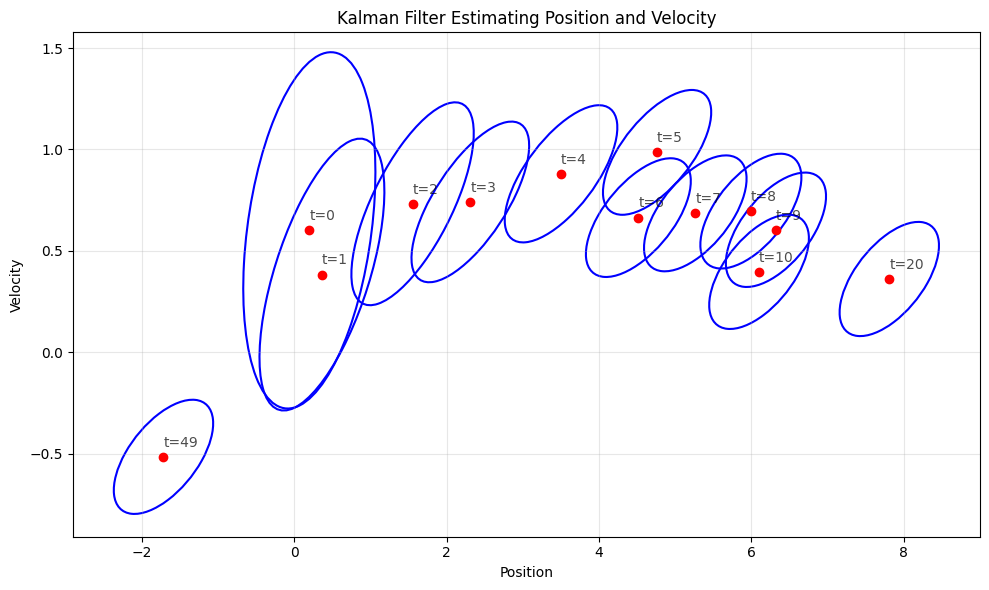

In [4]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Kalman Filter Estimating Position and Velocity")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.grid(True, alpha=0.3)

# Show only the means corresponding to the plotted ellipses
steps = [0, 1, 2, 3, 4, 5,6, 7, 8, 9, 10, 20, 49]
selected_means = m_filt[steps]


ax.scatter(selected_means[:, 0], selected_means[:, 1], color="red", zorder=3)

for t in steps:
    mean = m_filt[t]
    cov = C_filt[t]

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * np.sqrt(vals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor="blue",
        facecolor="none",
        lw=1.5
    )
    ax.add_patch(ellipse)

    ax.text(mean[0], mean[1] + 0.05, f"t={t}", fontsize=10, alpha=0.7)

plt.tight_layout()
plt.show()

In [5]:
def draw_uncertainty_ellipsoids(ax, means, covs, step=10, scale=2.0, alpha=0.10):
    """
    Draw full 3D covariance ellipsoids along the estimated trajectory.

    Parameters
    ----------
    ax : 3D matplotlib axis
    means : array, shape (T, state_dim)
        Filtered state means.
    covs : array, shape (T, state_dim, state_dim)
        Filtered state covariances.
    step : int
        Plot one ellipsoid every `step` time steps.
    scale : float
        Size multiplier. For example, scale=2 draws a 2-sigma ellipsoid.
    alpha : float
        Transparency of the ellipsoid surface.
    """
    # Unit sphere parameterisation
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)

    sphere_x = np.outer(np.cos(u), np.sin(v))
    sphere_y = np.outer(np.sin(u), np.sin(v))
    sphere_z = np.outer(np.ones_like(u), np.cos(v))

    sphere = np.stack([sphere_x, sphere_y, sphere_z], axis=0)  # shape (3, nu, nv)

    for t in range(0, len(means), step):
        # Position mean: take x, y, z components from [x, vx, y, vy, z, vz]
        mean = means[t, [0, 2, 4]]

        # Position covariance block
        Cpos = covs[t][np.ix_([0, 2, 4], [0, 2, 4])]

        # Eigen-decomposition of covariance
        vals, vecs = np.linalg.eigh(Cpos)

        # Sort by largest variance first
        order = vals.argsort()[::-1]
        vals = vals[order]
        vecs = vecs[:, order]

        # Semi-axis lengths of the ellipsoid
        radii = scale * np.sqrt(np.maximum(vals, 0.0))

        # Transform the unit sphere into the covariance ellipsoid
        ellipsoid = (
            vecs @ np.diag(radii) @ sphere.reshape(3, -1)
        ).reshape(3, sphere.shape[1], sphere.shape[2])

        X = ellipsoid[0] + mean[0]
        Y = ellipsoid[1] + mean[1]
        Z = ellipsoid[2] + mean[2]

        ax.plot_surface(
            X, Y, Z,
            color="lightskyblue",
            alpha=alpha,
            linewidth=0,
            shade=True
        )

c:\Github\Kalman-Filter-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


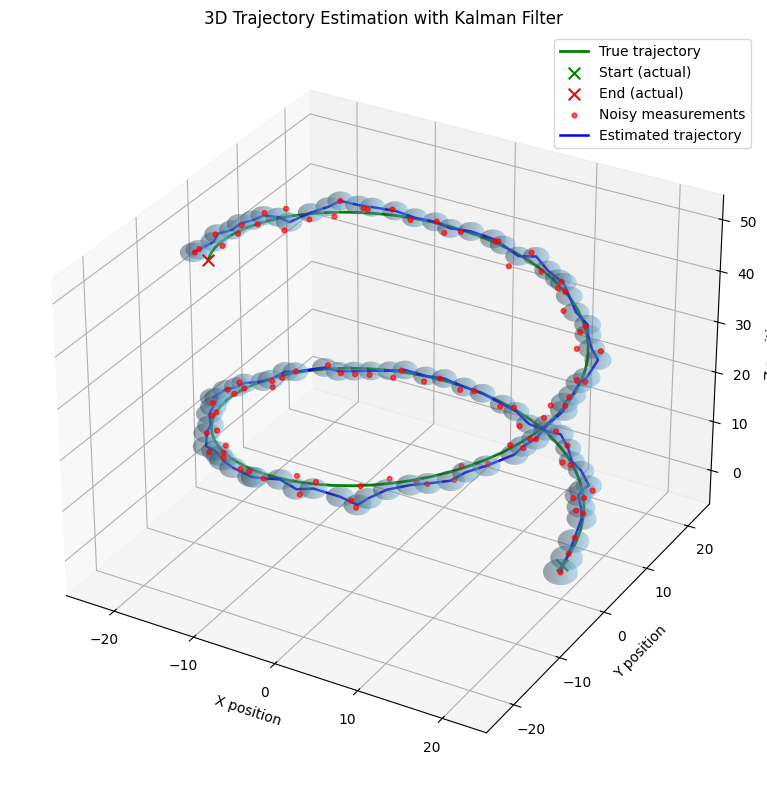

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# 3D tracking example 
# State: [x, vx, y, vy, z, vz]
# Observation: [x, y, z]


rng = np.random.default_rng(7)

# Time grid
T = 100
dt = 1.0
tgrid = np.arange(T)

# True 3D trajectory: a helix
radius = 20.0
omega = 0.1

true_x = radius * np.cos(omega * tgrid)
true_y = radius * np.sin(omega * tgrid)
true_z = 0.5 * tgrid

# Noisy position measurements
obs_std = 1.0
xs_3d = np.column_stack([
    true_x + rng.normal(0.0, obs_std, size=T),
    true_y + rng.normal(0.0, obs_std, size=T),
    true_z + rng.normal(0.0, obs_std, size=T),
])

# Constant-velocity state transition applied separately in x, y, z
F3 = np.array([
    [1.0, dt, 0.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, dt, 0.0, 0.0],
    [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0, dt],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
])

# Observe positions only
H3 = np.array([
    [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
])

# Small process noise, isotropic measurement noise
Q3 = 0.05 * np.eye(6)
R3 = (obs_std**2) * np.eye(3)

# Initial estimate:
# start near the first measurement and use a rough initial velocity guess
m0_3d = np.array([
    xs_3d[0, 0], 0.0,
    xs_3d[0, 1], 0.0,
    xs_3d[0, 2], 0.5,
])

C0_3d = np.diag([4.0, 2.0, 4.0, 2.0, 4.0, 2.0])

# Run the same Kalman filter class
kf_3d = KalmanFilterLGSSM(F=F3, Q=Q3, H=H3, R=R3, m0=m0_3d, C0=C0_3d)
out_3d = kf_3d.filter(xs_3d)

m_filt_3d = out_3d["m"]

# Extract filtered positions
x_est = m_filt_3d[:, 0]
y_est = m_filt_3d[:, 2]
z_est = m_filt_3d[:, 4]


# Plot true trajectory, noisy observations, and Kalman estimate
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# True path
ax.plot(true_x, true_y, true_z, color="green", linewidth=2.0, label="True trajectory")

# Start / end markers
ax.scatter(true_x[0], true_y[0], true_z[0], color="green", marker="x", s=70, label="Start (actual)")
ax.scatter(true_x[-1], true_y[-1], true_z[-1], color="red", marker="x", s=70, label="End (actual)")

# Noisy measurements
ax.scatter(xs_3d[:, 0], xs_3d[:, 1], xs_3d[:, 2], color="red", s=12, alpha=0.65, label="Noisy measurements")

# Filtered estimate
ax.plot(x_est, y_est, z_est, color="blue", linewidth=1.8, label="Estimated trajectory")

ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Z position")
ax.set_title("3D Trajectory Estimation with Kalman Filter")
ax.legend()

#draw uncertainty tube
draw_uncertainty_ellipsoids(ax, m_filt_3d, out_3d["C"], step=1, scale=2.0, alpha=0.3)
plt.tight_layout()
plt.show()